# **Easy Problem**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

In [3]:
def load_ecommerce_data(file_path, date_column, target_status):
    try:
        dataframe = pd.read_csv(file_path)
        dataframe[date_column] = pd.to_datetime(dataframe[date_column])
        filtered_dataframe = dataframe[dataframe['order_status'] == target_status]
        filtered_dataframe.set_index(date_column, inplace=True)
        return filtered_dataframe
    except Exception as error:
        print(error)
        return pd.DataFrame()

In [4]:
def aggregate_daily_sales(dataframe):
    try:
        if dataframe.empty:
            raise ValueError("Empty dataframe provided.")
        daily_sales_series = dataframe.resample('D').size().fillna(0)
        return daily_sales_series
    except Exception as error:
        print(error)
        return pd.Series()

In [5]:
def compute_adf_test(time_series):
    try:
        if len(time_series) == 0:
            raise ValueError("Time series is empty.")
        adf_result = adfuller(time_series)
        p_value = adf_result[1]
        return p_value
    except Exception as error:
        print(error)
        return None

In [6]:
def plot_time_series_components(time_series, seasonal_period):
    try:
        decomposition = seasonal_decompose(time_series, model='additive', period=seasonal_period)
        figure, axes = plt.subplots(4, 1, figsize=(10, 8))
        decomposition.observed.plot(ax=axes[0])
        decomposition.trend.plot(ax=axes[1])
        decomposition.seasonal.plot(ax=axes[2])
        decomposition.resid.plot(ax=axes[3])
        plt.tight_layout()
        plt.show()
        
        figure_acf, axes_acf = plt.subplots(1, 2, figsize=(12, 4))
        plot_acf(time_series, ax=axes_acf[0])
        plot_pacf(time_series, ax=axes_acf[1])
        plt.show()
    except Exception as error:
        print(error)

0.1258199854305347


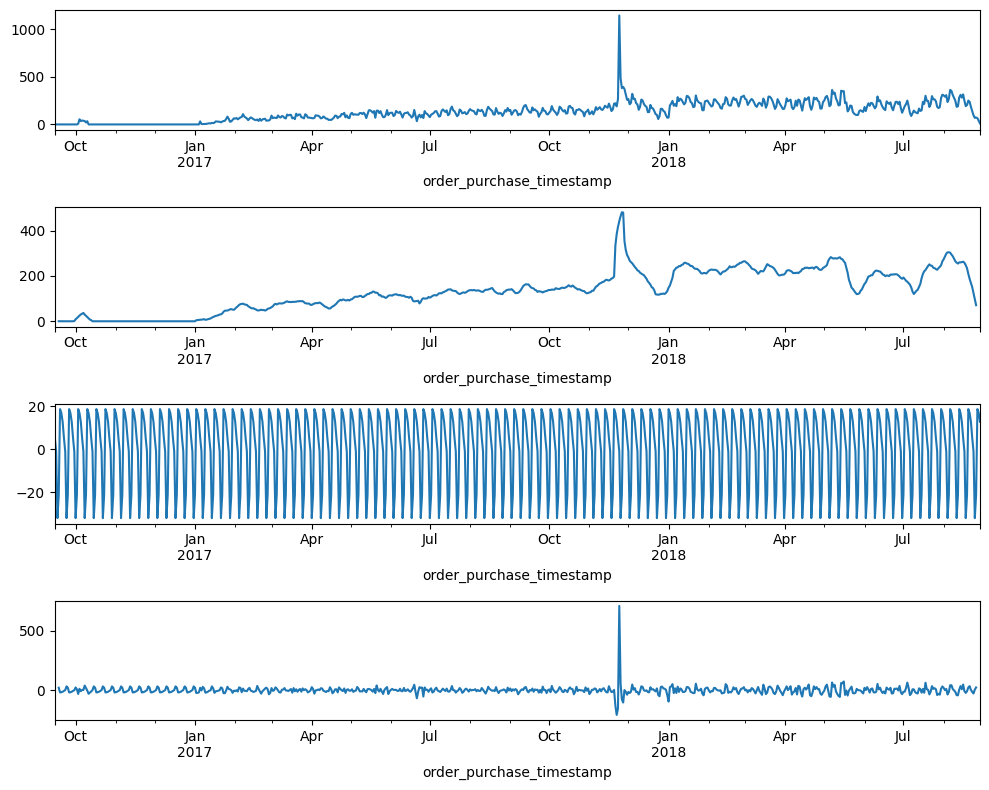

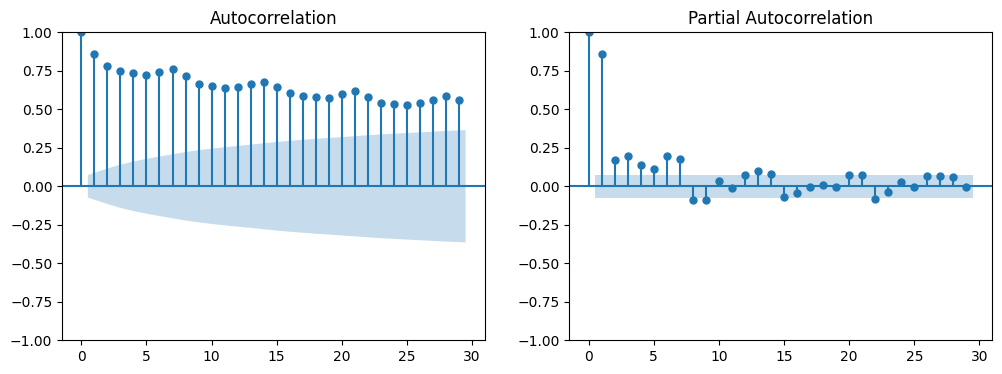

In [7]:
if __name__ == "__main__":
    DATA_FILE = "ecommerce_sales_ts.csv"
    DATE_COL = "order_purchase_timestamp"
    STATUS_DELIVERED = "delivered"
    SEASONAL_WINDOW = 7
    
    ecommerce_df = load_ecommerce_data(DATA_FILE, DATE_COL, STATUS_DELIVERED)
    daily_sales_ts = aggregate_daily_sales(ecommerce_df)
    
    adf_p_value = compute_adf_test(daily_sales_ts)
    print(adf_p_value)
    
    plot_time_series_components(daily_sales_ts, SEASONAL_WINDOW)

# **Medium Problem**

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

In [9]:
def chronological_train_test_split(time_series, train_ratio):
    try:
        if len(time_series) == 0:
            raise ValueError("Input series is empty.")
        split_index = int(len(time_series) * train_ratio)
        train_partition = time_series.iloc[:split_index]
        test_partition = time_series.iloc[split_index:]
        return train_partition, test_partition
    except Exception as error:
        print(error)
        return pd.Series(), pd.Series()

In [10]:
def train_sarima_model(train_data, forecast_steps, arima_order, seasonal_configuration):
    try:
        sarima_model = SARIMAX(train_data, order=arima_order, seasonal_order=seasonal_configuration)
        fitted_sarima = sarima_model.fit(disp=False)
        forecast_results = fitted_sarima.forecast(steps=forecast_steps)
        return forecast_results
    except Exception as error:
        print(error)
        return pd.Series()

In [11]:
def calculate_forecast_metrics(actual_values, predicted_values):
    try:
        if len(actual_values) != len(predicted_values):
            raise ValueError("Length mismatch between actuals and predictions.")
        rmse_score = np.sqrt(mean_squared_error(actual_values, predicted_values))
        mae_score = mean_absolute_error(actual_values, predicted_values)
        return rmse_score, mae_score
    except Exception as error:
        print(error)
        return None, None

In [12]:
if __name__ == "__main__":
    DATA_FILE = "ecommerce_sales_ts.csv"
    DATE_COL = "order_purchase_timestamp"
    STATUS_DELIVERED = "delivered"
    TRAIN_SPLIT_RATIO = 0.8
    ARIMA_PARAMS = (1, 1, 1)
    SARIMA_PARAMS = (1, 1, 1, 7)
    
    ecommerce_df = pd.read_csv(DATA_FILE)
    ecommerce_df[DATE_COL] = pd.to_datetime(ecommerce_df[DATE_COL])
    ecommerce_df = ecommerce_df[ecommerce_df['order_status'] == STATUS_DELIVERED]
    daily_sales_ts = ecommerce_df.set_index(DATE_COL).resample('D').size().fillna(0)
    
    train_ts, test_ts = chronological_train_test_split(daily_sales_ts, TRAIN_SPLIT_RATIO)
    
    test_length = len(test_ts)
    predictions = train_sarima_model(train_ts, test_length, ARIMA_PARAMS, SARIMA_PARAMS)
    
    if not predictions.empty:
        rmse, mae = calculate_forecast_metrics(test_ts, predictions)
        print(rmse, mae)

88.35779153482503 68.89582094488838


# **Hard Problerm**

In [5]:
import pandas as pd
from prophet import Prophet

def format_data_for_prophet(time_series):
    try:
        if time_series.empty:
            raise ValueError("Time series is empty.")
        prophet_dataframe = time_series.reset_index()
        prophet_dataframe.columns = ['ds', 'y']
        return prophet_dataframe
    except Exception as error:
        print(error)
        return pd.DataFrame()

def generate_prophet_forecast(train_dataframe, future_steps):
    try:
        prophet_model = Prophet(daily_seasonality=True, yearly_seasonality=True)
        prophet_model.fit(train_dataframe)
        future_dates = prophet_model.make_future_dataframe(periods=future_steps)
        forecast_output = prophet_model.predict(future_dates)
        return forecast_output
    except Exception as error:
        print(error)
        return pd.DataFrame()

def load_and_clean_sensor_data(file_path, time_column):
    try:
        sensor_dataframe = pd.read_csv(file_path)
        sensor_dataframe[time_column] = pd.to_datetime(sensor_dataframe[time_column], format='%d-%m-%রের %H:%M', errors='coerce')
        sensor_dataframe.set_index(time_column, inplace=True)
        
        sensor_dataframe.drop(columns=['Unnamed: 0', 'sensor_15'], errors='ignore', inplace=True)
        sensor_dataframe.fillna(method='ffill', inplace=True)
        sensor_dataframe.fillna(method='bfill', inplace=True)
        
        daily_sensor_aggregation = sensor_dataframe['sensor_00'].resample('D').mean()
        return daily_sensor_aggregation
    except Exception as error:
        print(error)
        return pd.Series()

if __name__ == "__main__":
    SALES_FILE = "ecommerce_sales_ts.csv"
    SENSOR_FILE = "sensor.csv"
    SALES_DATE_COL = "order_purchase_timestamp"
    SENSOR_DATE_COL = "timestamp"
    TRAIN_SPLIT_RATIO = 0.8
    
    ecommerce_df = pd.read_csv(SALES_FILE)
    ecommerce_df[SALES_DATE_COL] = pd.to_datetime(ecommerce_df[SALES_DATE_COL])
    daily_sales_ts = ecommerce_df[ecommerce_df['order_status'] == 'delivered'].set_index(SALES_DATE_COL).resample('D').size().fillna(0)
    
    split_idx = int(len(daily_sales_ts) * TRAIN_SPLIT_RATIO)
    train_sales_ts = daily_sales_ts.iloc[:split_idx]
    test_sales_ts = daily_sales_ts.iloc[split_idx:]
    
    prophet_train_df = format_data_for_prophet(train_sales_ts)
    test_duration = len(test_sales_ts)
    
    sales_forecast = generate_prophet_forecast(prophet_train_df, test_duration)
    cleaned_sensor_ts = load_and_clean_sensor_data(SENSOR_FILE, SENSOR_DATE_COL)

Importing plotly failed. Interactive plots will not work.
15:10:00 - cmdstanpy - INFO - Chain [1] start processing
15:10:00 - cmdstanpy - INFO - Chain [1] done processing


'র' is a bad directive in format '%d-%m-%রের %H:%M'
